In [1]:
# ============================================================
# 1. Imports
# ============================================================

import os
import sys
import json
import subprocess
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


In [2]:
# ============================================================
# 2. Paths and configuration
# ============================================================

PROJECT_DIR = Path.cwd()

DATA_SPLIT = PROJECT_DIR / "data_split.json"

# Same data location as your current Conditional DDPM notebook.
BRATS2023_DIR = (
    PROJECT_DIR
    / "Data"
    / "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
)

MED_DDPM_DIR = PROJECT_DIR / "med-ddpm"

PRETRAINED_WEIGHT = (
    MED_DDPM_DIR
    / "model"
    / "model_brats.pt"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "conditional_medddpm_results"
)

TARGET_H = 192
TARGET_W = 192
TARGET_D = 144

TUMOUR_LABELS = (1, 2, 3)
NUM_MASK_CHANNELS = len(TUMOUR_LABELS)

# 3 tumour-mask channels + 1 Shannon-entropy channel
NUM_CONDITION_CHANNELS = (
    NUM_MASK_CHANNELS + 1
)

TARGET_CHANNELS = 1

# noisy T2f + 4 condition channels
MODEL_INPUT_CHANNELS = (
    TARGET_CHANNELS
    + NUM_CONDITION_CHANNELS
)

MODEL_BASE_CHANNELS = 64
NUM_RES_BLOCKS = 2
DIFFUSION_STEPS = 250

BATCH_SIZE = 1
LEARNING_RATE = 1e-5
FINE_TUNE_STEPS = 10000
GRADIENT_ACCUMULATE_EVERY = 2
SAVE_EVERY = 1000

print("Project:", PROJECT_DIR)
print("BraTS2023:", BRATS2023_DIR)
print("Med-DDPM repo:", MED_DDPM_DIR)
print("Pretrained:", PRETRAINED_WEIGHT)
print("Target shape:", (TARGET_H, TARGET_W, TARGET_D))
print("Condition channels:", NUM_CONDITION_CHANNELS)
print("Model input channels:", MODEL_INPUT_CHANNELS)
print("Model output channels:", TARGET_CHANNELS)
print("Diffusion steps:", DIFFUSION_STEPS)


Project: /users/tdd540/Capstone_Project
BraTS2023: /users/tdd540/Capstone_Project/Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData
Med-DDPM repo: /users/tdd540/Capstone_Project/med-ddpm
Pretrained: /users/tdd540/Capstone_Project/med-ddpm/model/model_brats.pt
Target shape: (192, 192, 144)
Condition channels: 4
Model input channels: 5
Model output channels: 1
Diffusion steps: 250


In [3]:
# ============================================================
# 3. Download / prepare official Med-DDPM repository
# No Git installation required
# ============================================================

import sys
import shutil
import urllib.request
import zipfile
from pathlib import Path


MED_DDPM_DIR = (
    PROJECT_DIR
    / "med-ddpm"
)


if not MED_DDPM_DIR.exists():

    print(
        "Med-DDPM repository not found."
    )

    print(
        "Downloading official repository ZIP..."
    )


    zip_url = (
        "https://github.com/"
        "mobaidoctor/med-ddpm/"
        "archive/refs/heads/main.zip"
    )


    zip_path = (
        PROJECT_DIR
        / "med-ddpm-main.zip"
    )


    extract_dir = (
        PROJECT_DIR
        / "_med_ddpm_download"
    )


    # Download
    urllib.request.urlretrieve(
        zip_url,
        zip_path
    )


    print(
        "Download completed:",
        zip_path
    )


    # Remove old temporary folder
    if extract_dir.exists():

        shutil.rmtree(
            extract_dir
        )


    # Extract
    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            extract_dir
        )


    extracted_repo = (
        extract_dir
        / "med-ddpm-main"
    )


    if not extracted_repo.exists():

        raise FileNotFoundError(
            "Downloaded ZIP was extracted, "
            "but med-ddpm-main was not found."
        )


    # Move to expected location
    shutil.move(
        str(extracted_repo),
        str(MED_DDPM_DIR)
    )


    # Clean temporary files
    shutil.rmtree(
        extract_dir
    )


    zip_path.unlink(
        missing_ok=True
    )


    print(
        "Med-DDPM repository installed at:"
    )

    print(
        MED_DDPM_DIR
    )


else:

    print(
        "Med-DDPM repository already exists:"
    )

    print(
        MED_DDPM_DIR
    )


# Add repository to Python import path
if str(MED_DDPM_DIR) not in sys.path:

    sys.path.insert(
        0,
        str(MED_DDPM_DIR)
    )


# Basic structure checks
required_files = [

    MED_DDPM_DIR
    / "diffusion_model",

    MED_DDPM_DIR
    / "train_brats.py",

    MED_DDPM_DIR
    / "dataset_brats.py"
]


for path in required_files:

    if not path.exists():

        raise FileNotFoundError(
            f"Required Med-DDPM file/folder "
            f"not found: {path}"
        )


print()
print(
    "Med-DDPM repository: PASS"
)


# ============================================================
# Check pretrained weights separately
# ============================================================

if PRETRAINED_WEIGHT.exists():

    print(
        "Pretrained checkpoint: FOUND"
    )

    print(
        PRETRAINED_WEIGHT
    )

else:

    print()
    print(
        "Pretrained checkpoint: NOT FOUND"
    )

    print(
        "Expected location:"
    )

    print(
        PRETRAINED_WEIGHT
    )

    print()
    print(
        "Repository code is ready, "
        "but the pretrained BraTS weight "
        "still needs to be downloaded separately."
    )

Med-DDPM repository already exists:
/users/tdd540/Capstone_Project/med-ddpm

Med-DDPM repository: PASS
Pretrained checkpoint: FOUND
/users/tdd540/Capstone_Project/med-ddpm/model/model_brats.pt


In [4]:
# ============================================================
# 4. Import official Med-DDPM implementation
# ============================================================

from diffusion_model.unet_brats import create_model
from diffusion_model.trainer_brats import GaussianDiffusion

print("Med-DDPM imports: PASS")


APEX: OFF
Med-DDPM imports: PASS


In [5]:
# ============================================================
# 5. Load existing project split
# ============================================================

with open(
    DATA_SPLIT,
    "r"
) as f:
    split_data = json.load(f)

train_subjects = split_data["train"]
val_subjects = split_data["validation"]
test_subjects = split_data["test"]

print("Train:", len(train_subjects))
print("Validation:", len(val_subjects))
print("Test:", len(test_subjects))


Train: 1000
Validation: 125
Test: 126


In [6]:
# ============================================================
# 6. Pre-processing helpers
# ============================================================

def normalize_t2f(image):
    image = image.astype(
        np.float32
    )

    foreground = image > 0

    if not np.any(foreground):
        raise ValueError(
            "No brain foreground found."
        )

    upper = np.percentile(
        image[foreground],
        99.9
    )

    if upper <= 0:
        raise ValueError(
            "Invalid T2-FLAIR upper percentile."
        )

    image = np.clip(
        image,
        0,
        upper
    )

    image = image / upper
    image = image * 2.0 - 1.0

    image[~foreground] = -1.0

    return image.astype(
        np.float32
    )


def calculate_tumour_entropy(
    image_minus1_1,
    mask,
    num_bins=256
):
    tumour = mask > 0

    if not np.any(tumour):
        return np.float32(0.0)

    image_01 = np.clip(
        (
            image_minus1_1
            + 1.0
        )
        / 2.0,
        0.0,
        1.0
    )

    values = image_01[tumour]

    hist, _ = np.histogram(
        values,
        bins=num_bins,
        range=(0.0, 1.0)
    )

    probabilities = hist.astype(
        np.float64
    )

    total = probabilities.sum()

    if total <= 0:
        return np.float32(0.0)

    probabilities /= total

    probabilities = probabilities[
        probabilities > 0
    ]

    entropy = -np.sum(
        probabilities
        * np.log2(
            probabilities
        )
    )

    return np.float32(
        entropy
    )


def resize_volume_trilinear(
    volume_hwd
):
    tensor = torch.from_numpy(
        volume_hwd.astype(
            np.float32
        )
    ).permute(
        2, 0, 1
    ).unsqueeze(
        0
    ).unsqueeze(
        0
    )

    tensor = F.interpolate(
        tensor,
        size=(
            TARGET_D,
            TARGET_H,
            TARGET_W
        ),
        mode="trilinear",
        align_corners=False
    )

    return tensor[0, 0]


def resize_mask_nearest(
    mask_hwd
):
    tensor = torch.from_numpy(
        mask_hwd.astype(
            np.float32
        )
    ).permute(
        2, 0, 1
    ).unsqueeze(
        0
    ).unsqueeze(
        0
    )

    tensor = F.interpolate(
        tensor,
        size=(
            TARGET_D,
            TARGET_H,
            TARGET_W
        ),
        mode="nearest"
    )

    return tensor[0, 0].long()


def mask_to_onehot(
    resized_mask
):
    channels = []

    for label in TUMOUR_LABELS:
        channels.append(
            (
                resized_mask
                == label
            ).float()
        )

    return torch.stack(
        channels,
        dim=0
    )


In [7]:
# ============================================================
# 7. BraTS 2023 -> Med-DDPM adapter dataset
#
# target: [1, 144, 192, 192]
# input : [4, 144, 192, 192]
#         3 tumour masks + 1 entropy channel
# ============================================================

class BraTS2023MedDDPMDataset(
    Dataset
):

    def __init__(
        self,
        subjects,
        data_dir,
        entropy_mean=None,
        entropy_std=None
    ):
        self.subjects = subjects
        self.data_dir = Path(
            data_dir
        )

        self.entropy_mean = (
            entropy_mean
        )

        self.entropy_std = (
            entropy_std
        )


    def __len__(self):
        return len(
            self.subjects
        )


    def _find_files(
        self,
        subject
    ):
        subject_dir = (
            self.data_dir
            / subject
        )

        if not subject_dir.exists():
            raise FileNotFoundError(
                f"Missing subject directory: "
                f"{subject_dir}"
            )

        files = list(
            subject_dir.iterdir()
        )

        t2f = [
            p for p in files
            if "t2f" in p.name.lower()
            and p.name.endswith(
                ".nii.gz"
            )
        ]

        seg = [
            p for p in files
            if "seg" in p.name.lower()
            and p.name.endswith(
                ".nii.gz"
            )
        ]

        if len(t2f) == 0:
            raise FileNotFoundError(
                f"No T2-FLAIR found "
                f"for {subject}"
            )

        if len(seg) == 0:
            raise FileNotFoundError(
                f"No segmentation found "
                f"for {subject}"
            )

        return (
            t2f[0],
            seg[0]
        )


    def raw_entropy(
        self,
        idx
    ):
        subject = self.subjects[
            idx
        ]

        (
            t2f_path,
            seg_path
        ) = self._find_files(
            subject
        )

        image = nib.load(
            str(t2f_path)
        ).get_fdata()

        mask = nib.load(
            str(seg_path)
        ).get_fdata().astype(
            np.int64
        )

        image = normalize_t2f(
            image
        )

        return (
            calculate_tumour_entropy(
                image,
                mask
            )
        )


    def __getitem__(
        self,
        idx
    ):
        subject = self.subjects[
            idx
        ]

        (
            t2f_path,
            seg_path
        ) = self._find_files(
            subject
        )

        image = nib.load(
            str(t2f_path)
        ).get_fdata()

        mask = nib.load(
            str(seg_path)
        ).get_fdata().astype(
            np.int64
        )

        image = normalize_t2f(
            image
        )

        entropy = (
            calculate_tumour_entropy(
                image,
                mask
            )
        )

        image_tensor = (
            resize_volume_trilinear(
                image
            )
            .unsqueeze(0)
            .float()
        )

        mask_tensor = (
            resize_mask_nearest(
                mask
            )
        )

        mask_onehot = (
            mask_to_onehot(
                mask_tensor
            )
        )

        if (
            self.entropy_mean
            is not None
            and self.entropy_std
            is not None
            and self.entropy_std > 0
        ):
            entropy_z = (
                float(entropy)
                - float(
                    self.entropy_mean
                )
            ) / float(
                self.entropy_std
            )
        else:
            entropy_z = float(
                entropy
            )

        entropy_channel = (
            torch.full(
                (
                    1,
                    TARGET_D,
                    TARGET_H,
                    TARGET_W
                ),
                fill_value=entropy_z,
                dtype=torch.float32
            )
        )

        condition = torch.cat(
            [
                mask_onehot,
                entropy_channel
            ],
            dim=0
        )

        return {
            "input": condition,
            "target": image_tensor,
            "subject": subject,
            "entropy": torch.tensor(
                entropy,
                dtype=torch.float32
            )
        }


In [8]:
# ============================================================
# 8. Compute / load entropy statistics
# ============================================================

ENTROPY_STATS_FILE = (
    PROJECT_DIR
    / "medddpm_brats2023_entropy_stats.npz"
)

entropy_probe_dataset = (
    BraTS2023MedDDPMDataset(
        train_subjects,
        BRATS2023_DIR
    )
)

if ENTROPY_STATS_FILE.exists():

    stats = np.load(
        ENTROPY_STATS_FILE
    )

    ENTROPY_MEAN = float(
        stats["mean"]
    )

    ENTROPY_STD = float(
        stats["std"]
    )

    print(
        "Loaded cached entropy statistics."
    )

else:

    print(
        "Computing whole-tumour "
        "T2-FLAIR Shannon entropy..."
    )

    values = []

    for i in range(
        len(
            entropy_probe_dataset
        )
    ):
        values.append(
            entropy_probe_dataset
            .raw_entropy(i)
        )

        if (
            (i + 1) % 100
            == 0
        ):
            print(
                f"Processed "
                f"{i + 1}/"
                f"{len(entropy_probe_dataset)}"
            )

    values = np.asarray(
        values,
        dtype=np.float32
    )

    ENTROPY_MEAN = float(
        values.mean()
    )

    ENTROPY_STD = float(
        values.std()
    )

    np.savez(
        ENTROPY_STATS_FILE,
        mean=ENTROPY_MEAN,
        std=ENTROPY_STD
    )

    print(
        "Saved:",
        ENTROPY_STATS_FILE
    )


print(
    "Entropy mean:",
    ENTROPY_MEAN
)

print(
    "Entropy std:",
    ENTROPY_STD
)

assert ENTROPY_STD > 0


Loaded cached entropy statistics.
Entropy mean: 6.870205879211426
Entropy std: 0.33203670382499695


In [9]:
# ============================================================
# 9. Final dataset + shape test
# ============================================================

train_dataset = (
    BraTS2023MedDDPMDataset(
        train_subjects,
        BRATS2023_DIR,
        entropy_mean=ENTROPY_MEAN,
        entropy_std=ENTROPY_STD
    )
)

sample = train_dataset[0]

print(
    "Subject:",
    sample["subject"]
)

print(
    "Target T2f:",
    tuple(
        sample["target"].shape
    )
)

print(
    "Condition:",
    tuple(
        sample["input"].shape
    )
)

print(
    "Raw entropy:",
    sample["entropy"].item()
)

for i, label in enumerate(
    TUMOUR_LABELS
):
    print(
        f"Mask label {label} voxels:",
        int(
            sample["input"][i]
            .sum()
            .item()
        )
    )

assert tuple(
    sample["target"].shape
) == (
    1,
    TARGET_D,
    TARGET_H,
    TARGET_W
)

assert tuple(
    sample["input"].shape
) == (
    NUM_CONDITION_CHANNELS,
    TARGET_D,
    TARGET_H,
    TARGET_W
)

print(
    "BraTS2023 -> Med-DDPM "
    "data adapter: PASS"
)


Subject: BraTS-GLI-00240-000
Target T2f: (1, 144, 192, 192)
Condition: (4, 144, 192, 192)
Raw entropy: 6.783998489379883
Mask label 1 voxels: 8985
Mask label 2 voxels: 63649
Mask label 3 voxels: 13036
BraTS2023 -> Med-DDPM data adapter: PASS


In [10]:
# ============================================================
# 10. Create adapted Med-DDPM model
# Memory-optimised version
#
# Keep gradient checkpointing.
# Do NOT convert model itself to fp16.
# AMP will be handled externally.
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


denoise_model = create_model(
    image_size=TARGET_H,
    num_channels=MODEL_BASE_CHANNELS,
    num_res_blocks=NUM_RES_BLOCKS,

    in_channels=MODEL_INPUT_CHANNELS,
    out_channels=TARGET_CHANNELS,

    use_checkpoint=True,

    # IMPORTANT:
    # keep model parameters in float32
    use_fp16=False,

).to(device)


diffusion = GaussianDiffusion(
    denoise_model,

    image_size=TARGET_H,
    depth_size=TARGET_D,

    timesteps=DIFFUSION_STEPS,

    loss_type="l1",

    with_condition=True,

    channels=TARGET_CHANNELS

).to(device)


print(
    "Gradient checkpointing:",
    True
)

print(
    "Model parameters:",
    "float32"
)

print(
    "External AMP:",
    "enabled during training"
)

Gradient checkpointing: True
Model parameters: float32
External AMP: enabled during training


In [11]:
# ============================================================
# 11. Partial pretrained-weight loading
# ============================================================

def load_compatible_pretrained(
    model,
    checkpoint_path
):
    checkpoint_path = Path(
        checkpoint_path
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            "Pretrained Med-DDPM checkpoint "
            "not found:\n"
            f"{checkpoint_path}"
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu"
    )

    if "ema" in checkpoint:
        pretrained = checkpoint[
            "ema"
        ]
        source_name = "ema"

    elif "model" in checkpoint:
        pretrained = checkpoint[
            "model"
        ]
        source_name = "model"

    else:
        pretrained = checkpoint
        source_name = (
            "raw state_dict"
        )

    current = model.state_dict()

    compatible = {}
    skipped_shape = []
    missing_in_current = []

    for key, value in (
        pretrained.items()
    ):
        if key not in current:
            missing_in_current.append(
                key
            )
            continue

        if (
            current[key].shape
            != value.shape
        ):
            skipped_shape.append(
                (
                    key,
                    tuple(value.shape),
                    tuple(
                        current[
                            key
                        ].shape
                    )
                )
            )
            continue

        compatible[key] = value

    result = model.load_state_dict(
        compatible,
        strict=False
    )

    print(
        "Checkpoint source:",
        source_name
    )

    print(
        "Compatible tensors loaded:",
        len(compatible)
    )

    print(
        "Shape-mismatched tensors skipped:",
        len(skipped_shape)
    )

    print(
        "Keys absent in adapted model:",
        len(missing_in_current)
    )

    print(
        "Adapted-model missing keys:",
        len(
            result.missing_keys
        )
    )

    print(
        "Adapted-model unexpected keys:",
        len(
            result.unexpected_keys
        )
    )

    print()

    for item in (
        skipped_shape[:10]
    ):
        print(
            "SKIP:",
            item
        )

    return {
        "loaded":
            compatible,
        "skipped_shape":
            skipped_shape,
        "load_result":
            result
    }


pretrained_report = (
    load_compatible_pretrained(
        diffusion,
        PRETRAINED_WEIGHT
    )
)


Checkpoint source: ema
Compatible tensors loaded: 348
Shape-mismatched tensors skipped: 3
Keys absent in adapted model: 0
Adapted-model missing keys: 3
Adapted-model unexpected keys: 0

SKIP: ('denoise_fn.input_blocks.0.0.weight', (64, 8, 3, 3, 3), (64, 5, 3, 3, 3))
SKIP: ('denoise_fn.out.2.weight', (4, 64, 3, 3, 3), (1, 64, 3, 3, 3))
SKIP: ('denoise_fn.out.2.bias', (4,), (1,))


In [12]:
# ============================================================
# 12. One-batch forward/backward smoke test
#
# Memory strategy:
# - gradient checkpointing = ON
# - model parameters = FP32
# - external AMP autocast = ON
# ============================================================

import gc


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


train_loader = DataLoader(

    train_dataset,

    batch_size=1,

    shuffle=True,

    num_workers=0,

    pin_memory=True

)


batch = next(
    iter(train_loader)
)


condition = batch[
    "input"
].to(
    device,
    non_blocking=True
)


target = batch[
    "target"
].to(
    device,
    non_blocking=True
)


print(
    "Condition:",
    tuple(
        condition.shape
    )
)

print(
    "Target:",
    tuple(
        target.shape
    )
)

print(
    "Condition dtype:",
    condition.dtype
)

print(
    "Target dtype:",
    target.dtype
)


diffusion.train()


optimizer = torch.optim.AdamW(
    diffusion.parameters(),
    lr=LEARNING_RATE
)


optimizer.zero_grad(
    set_to_none=True
)


use_amp = (
    device.type == "cuda"
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)


# ============================================================
# Forward
# ============================================================

with torch.amp.autocast(
    device_type="cuda",
    dtype=torch.float16,
    enabled=use_amp
):

    loss = diffusion(
        target,
        condition_tensors=condition
    )


print(
    "Loss:",
    loss.item()
)


assert torch.isfinite(
    loss
)


print(
    "Forward: PASS"
)


# ============================================================
# Backward
# ============================================================

scaler.scale(
    loss
).backward()


scaler.unscale_(
    optimizer
)


gradient_found = False
finite_gradients = True


for name, parameter in (
    diffusion.named_parameters()
):

    if parameter.grad is not None:

        gradient_found = True

        if not torch.isfinite(
            parameter.grad
        ).all():

            finite_gradients = False

            print(
                "Non-finite gradient:",
                name
            )

            break


assert gradient_found
assert finite_gradients


print(
    "Backward: PASS"
)

print(
    "Finite gradients: PASS"
)


# ============================================================
# GPU memory
# ============================================================

if torch.cuda.is_available():

    allocated = (
        torch.cuda.memory_allocated()
        /
        1024**3
    )

    reserved = (
        torch.cuda.memory_reserved()
        /
        1024**3
    )

    peak = (
        torch.cuda.max_memory_allocated()
        /
        1024**3
    )


    print()

    print(
        "GPU memory:"
    )

    print(
        f"Allocated: "
        f"{allocated:.2f} GB"
    )

    print(
        f"Reserved: "
        f"{reserved:.2f} GB"
    )

    print(
        f"Peak: "
        f"{peak:.2f} GB"
    )


optimizer.zero_grad(
    set_to_none=True
)


del batch
del condition
del target
del loss


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


print()

print("=" * 72)

print(
    "MED-DDPM SMOKE TEST: PASS"
)

print("=" * 72)

Condition: (1, 4, 144, 192, 192)
Target: (1, 1, 144, 192, 192)
Condition dtype: torch.float32
Target dtype: torch.float32


Loss: 0.7981853485107422
Forward: PASS


Backward: PASS
Finite gradients: PASS

GPU memory:
Allocated: 0.55 GB
Reserved: 27.28 GB
Peak: 19.94 GB

MED-DDPM SMOKE TEST: PASS


In [13]:
# ============================================================
# 13. Fine-tuning loop
# Resume from Step 6000 -> Step 10000
# ============================================================

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_DIR = (
    RESULTS_DIR
    / "checkpoints"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOSS_FILE = (
    RESULTS_DIR
    / "finetune_loss.npy"
)


# ============================================================
# 1. Create optimizer
# ============================================================

optimizer = torch.optim.Adam(
    diffusion.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# 2. Resume checkpoint
# ============================================================

RESUME_CHECKPOINT = (
    CHECKPOINT_DIR
    / "conditional_medddpm_step_006000.pt"
)

if not RESUME_CHECKPOINT.exists():

    raise FileNotFoundError(
        "Resume checkpoint not found:\n"
        f"{RESUME_CHECKPOINT}"
    )


print(
    "Loading resume checkpoint:",
    RESUME_CHECKPOINT
)


checkpoint = torch.load(
    RESUME_CHECKPOINT,
    map_location=device
)


diffusion.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


optimizer.load_state_dict(
    checkpoint[
        "optimizer_state_dict"
    ]
)


start_step = int(
    checkpoint["step"]
)


assert start_step == 6000, (
    f"Expected Step 6000 checkpoint, "
    f"but checkpoint contains Step {start_step}"
)


print(
    "Resume checkpoint loaded: PASS"
)

print(
    "Loaded step:",
    start_step
)

print(
    "Next step:",
    start_step + 1
)

print(
    "Final step:",
    FINE_TUNE_STEPS
)


# ============================================================
# 3. Restore previous loss history
# ============================================================

if LOSS_FILE.exists():

    loss_history = (
        np.load(
            LOSS_FILE
        )
        .tolist()
    )

    print(
        "Previous loss history loaded:",
        len(loss_history),
        "entries"
    )

else:

    loss_history = []

    print(
        "WARNING: previous loss history "
        "not found."
    )


# ============================================================
# 4. Training preparation
# ============================================================

data_iterator = iter(
    train_loader
)

diffusion.train()


# ============================================================
# 5. Resume fine-tuning
# Step 6001 -> Step 10000
# ============================================================

for step in range(
    start_step + 1,
    FINE_TUNE_STEPS + 1
):

    optimizer.zero_grad(
        set_to_none=True
    )

    accumulated = 0.0


    for _ in range(
        GRADIENT_ACCUMULATE_EVERY
    ):

        try:

            batch = next(
                data_iterator
            )

        except StopIteration:

            data_iterator = iter(
                train_loader
            )

            batch = next(
                data_iterator
            )


        condition = (
            batch["input"]
            .to(
                device,
                non_blocking=True
            )
        )


        target = (
            batch["target"]
            .to(
                device,
                non_blocking=True
            )
        )


        loss = diffusion(
            target,
            condition_tensors=condition
        )


        (
            loss
            / GRADIENT_ACCUMULATE_EVERY
        ).backward()


        accumulated += (
            loss.item()
            / GRADIENT_ACCUMULATE_EVERY
        )


    torch.nn.utils.clip_grad_norm_(
        diffusion.parameters(),
        1.0
    )


    optimizer.step()


    loss_history.append(
        accumulated
    )


    if (
        step == start_step + 1
        or step % 10 == 0
    ):

        print(
            f"Step "
            f"{step}/"
            f"{FINE_TUNE_STEPS} | "
            f"Loss="
            f"{accumulated:.6f}"
        )


    # ========================================================
    # Save checkpoint
    # ========================================================

    if (
        step % SAVE_EVERY
        == 0
        or step
        == FINE_TUNE_STEPS
    ):

        checkpoint_path = (
            CHECKPOINT_DIR
            / (
                "conditional_medddpm_"
                f"step_{step:06d}.pt"
            )
        )


        torch.save(
            {
                "step":
                    step,

                "model_state_dict":
                    diffusion.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "entropy_mean":
                    ENTROPY_MEAN,

                "entropy_std":
                    ENTROPY_STD,

                "tumour_labels":
                    TUMOUR_LABELS,

                "target_shape":
                    (
                        TARGET_H,
                        TARGET_W,
                        TARGET_D
                    ),
            },
            checkpoint_path
        )


        np.save(
            LOSS_FILE,
            np.asarray(
                loss_history,
                dtype=np.float32
            )
        )


        print(
            "Saved:",
            checkpoint_path
        )


print(
    "Fine-tuning completed."
)

Loading resume checkpoint: /users/tdd540/Capstone_Project/conditional_medddpm_results/checkpoints/conditional_medddpm_step_006000.pt


Resume checkpoint loaded: PASS
Loaded step: 6000
Next step: 6001
Final step: 10000
Previous loss history loaded: 6000 entries


[W827 11:40:04.051384726 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 4083154944 bytes (free: 2126315520, total: 47699722240).


Step 6001/10000 | Loss=0.054846


Step 6010/10000 | Loss=0.020279


...

Step 9970/10000 | Loss=0.043814


Step 9980/10000 | Loss=0.021979


Step 9990/10000 | Loss=0.010433


Step 10000/10000 | Loss=0.012774


Saved: /users/tdd540/Capstone_Project/conditional_medddpm_results/checkpoints/conditional_medddpm_step_010000.pt
Fine-tuning completed.


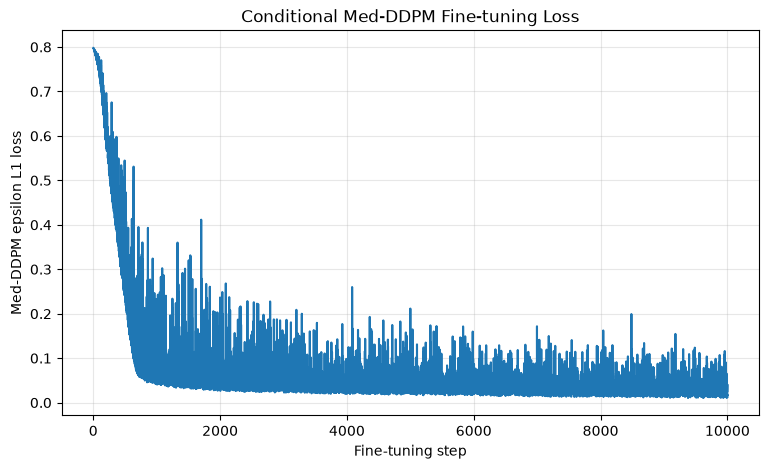

In [14]:
# ============================================================
# 14. Loss plot
# ============================================================

loss_history = np.load(
    LOSS_FILE
)

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    np.arange(
        1,
        len(loss_history) + 1
    ),
    loss_history
)

plt.xlabel(
    "Fine-tuning step"
)

plt.ylabel(
    "Med-DDPM epsilon L1 loss"
)

plt.title(
    "Conditional Med-DDPM Fine-tuning Loss"
)

plt.grid(
    alpha=0.3
)

plt.show()


sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 1/250 [00:01<04:28,  1.08s/it]

sampling loop time step:   1%|          | 3/250 [00:02<02:49,  1.46it/s]

sampling loop time step:   2%|▏         | 4/250 [00:03<03:21,  1.22it/s]

sampling loop time step:   2%|▏         | 5/250 [00:04<03:42,  1.10it/s]

...

sampling loop time step:  99%|█████████▉| 248/250 [04:26<00:02,  1.08s/it]

sampling loop time step: 100%|█████████▉| 249/250 [04:27<00:01,  1.08s/it]

sampling loop time step: 100%|██████████| 250/250 [04:28<00:00,  1.08s/it]

sampling loop time step: 100%|██████████| 250/250 [04:28<00:00,  1.08s/it]

Generated: (1, 1, 144, 192, 192)


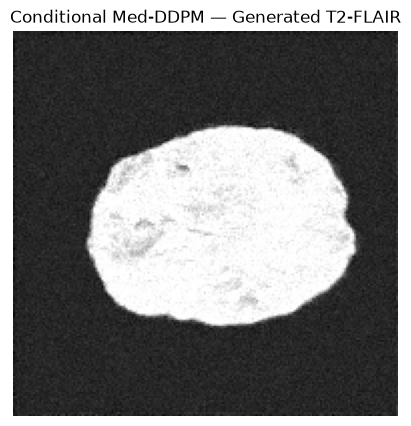

In [15]:
# ============================================================
# 15. Conditional sampling test
# ============================================================

diffusion.eval()

sample = train_dataset[0]

condition = (
    sample["input"]
    .unsqueeze(0)
    .to(device)
)

with torch.no_grad():

    generated = diffusion.sample(
        batch_size=1,
        condition_tensors=condition
    )

print(
    "Generated:",
    tuple(
        generated.shape
    )
)

generated_np = (
    generated[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)

middle = (
    generated_np.shape[0]
    // 2
)

plt.figure(
    figsize=(5, 5)
)

plt.imshow(
    generated_np[
        middle
    ],
    cmap="gray"
)

plt.title(
    "Conditional Med-DDPM — Generated T2-FLAIR"
)

plt.axis(
    "off"
)

plt.show()
